### 05 - GAM (Generalized Additive Model)

LinearGAM from pygam to predict demand_log. Same train/test split as the LM (2022-2024 / 2025).

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from pygam import LinearGAM, s, l, f
from sklearn.metrics import mean_squared_error, mean_absolute_error

plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 13})
os.makedirs('../outputs/figures/05_gam', exist_ok=True)

df = pd.read_csv('../data/processed/hourly_merged.csv', index_col='datetime_utc')
df.index = pd.to_datetime(df.index, utc=True)

# season needs to be integer-coded for pygam's f() term
season_map = {'winter': 0, 'spring': 1, 'summer': 2, 'autumn': 3}
df['season_num'] = df['season'].map(season_map)

print(f'Shape: {df.shape}')
df.head(3)

Shape: (35045, 20)


,demand,T,Hr,StrGlo,RainDur,WVv,p,hour,dayofweek,month,is_weekend,season,hour_sin,hour_cos,month_sin,month_cos,demand_log,is_peak,peak_hours_per_day,season_num
datetime_utc,,,,,,,,,,,,,,,,,,,,
2022-01-01 00:00:00+00:00,60787.89700,6.78,83.34,0.02,0.0,0.90,977.07,1,5,1,1,winter,0.258819,0.965926,0.5,0.866025,11.015146,0,0,0
2022-01-01 01:00:00+00:00,59943.68675,6.42,84.66,0.03,0.0,0.70,977.14,2,5,1,1,winter,0.500000,0.866025,0.5,0.866025,11.001161,0,0,0
2022-01-01 02:00:00+00:00,57751.22200,6.15,84.61,0.02,0.0,0.49,977.38,3,5,1,1,winter,0.707107,0.707107,0.5,0.866025,10.963900,0,0,0


#### 1. Train / Test Split

In [2]:
# feature columns in fixed order — the index matters for pygam
FEATURES = ['T', 'Hr', 'StrGlo', 'hour_sin', 'hour_cos',
            'month_sin', 'month_cos',
            'RainDur', 'WVv', 'p', 'is_weekend', 'season_num']
# indices: 0-6 splines, 7-10 linear, 11 factor

train = df[df.index.year < 2025].dropna(subset=FEATURES)
test  = df[df.index.year == 2025].dropna(subset=FEATURES)

X_train = train[FEATURES].values
y_train = train['demand_log'].values

X_test = test[FEATURES].values
y_test = test['demand_log'].values

print(f'Train: {len(train):,}   Test: {len(test):,}')

Train: 26,260   Test: 8,748


#### 2. GAM

Splines for the weather and cyclic features, linear terms for rain/wind/pressure/weekend,
and a factor term for season. Lambda chosen by GCV grid search.

In [3]:
gam = LinearGAM(
    s(0) + s(1) + s(2) +           # T, Hr, StrGlo
    s(3) + s(4) + s(5) + s(6) +    # hour_sin, hour_cos, month_sin, month_cos
    l(7) + l(8) + l(9) + l(10) +   # RainDur, WVv, p, is_weekend
    f(11)                           # season
)

# GCV grid search over lambda (smoothing penalty)
gam.gridsearch(X_train, y_train, lam=np.logspace(-3, 3, 25), progress=False)

print(f'Best lam : {gam.lam}')
print(f'GCV score: {gam.statistics_["GCV"]:.6f}')
print(f'R2 (train): {gam.statistics_["pseudo_r2"]["explained_deviance"]:.4f}')

Best lam : [[np.float64(0.03162277660168379)], [np.float64(0.03162277660168379)], [np.float64(0.03162277660168379)], [np.float64(0.03162277660168379)], [np.float64(0.03162277660168379)], [np.float64(0.03162277660168379)], [np.float64(0.03162277660168379)], [np.float64(0.03162277660168379)], [np.float64(0.03162277660168379)], [np.float64(0.03162277660168379)], [np.float64(0.03162277660168379)], [np.float64(0.03162277660168379)]]
GCV score: 0.008889
R2 (train): 0.8081


#### 3. Partial Dependence Plots

The estimated smooth effect of each predictor on log demand, with 95% CI.

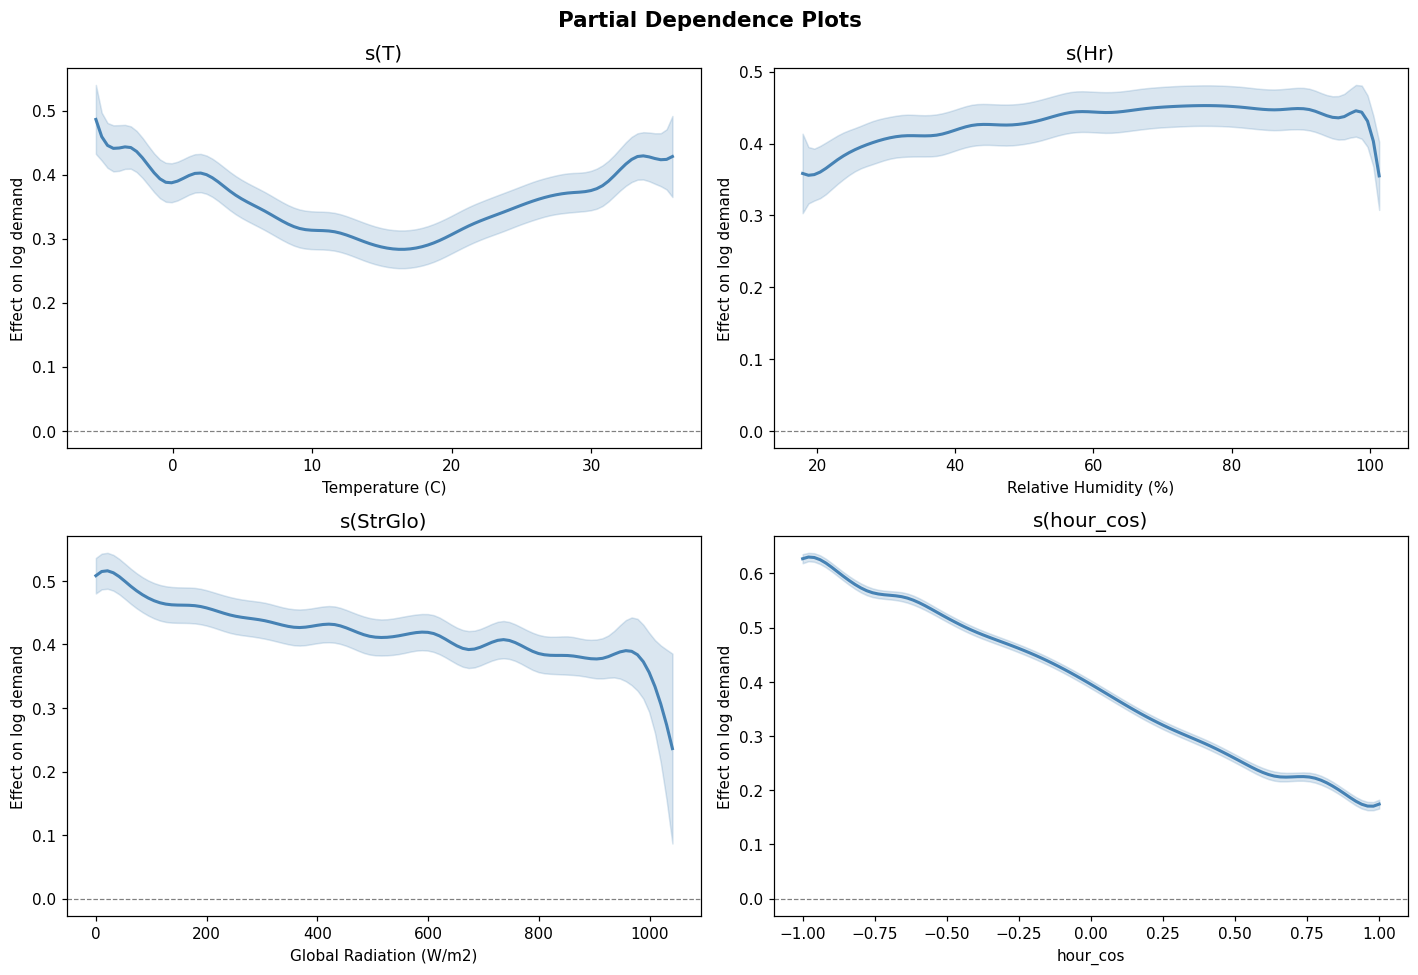

In [4]:
pdp_terms = [
    (0, 'T',       'Temperature (C)'),
    (1, 'Hr',      'Relative Humidity (%)'),
    (2, 'StrGlo',  'Global Radiation (W/m2)'),
    (4, 'hour_cos','hour_cos'),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, (term_idx, col, label) in zip(axes.flat, pdp_terms):
    XX   = gam.generate_X_grid(term=term_idx)
    pdep, conf = gam.partial_dependence(term=term_idx, X=XX, width=0.95)
    x_vals = XX[:, term_idx]

    ax.plot(x_vals, pdep, color='steelblue', lw=2)
    ax.fill_between(x_vals, conf[:, 0], conf[:, 1],
                    alpha=0.2, color='steelblue')
    ax.axhline(0, color='grey', lw=0.8, ls='--')
    ax.set_xlabel(label)
    ax.set_ylabel('Effect on log demand')
    ax.set_title(f's({col})')

fig.suptitle('Partial Dependence Plots', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/05_gam/05_13_gam_pdp.png', bbox_inches='tight')
plt.show()

#### 4. Diagnostics

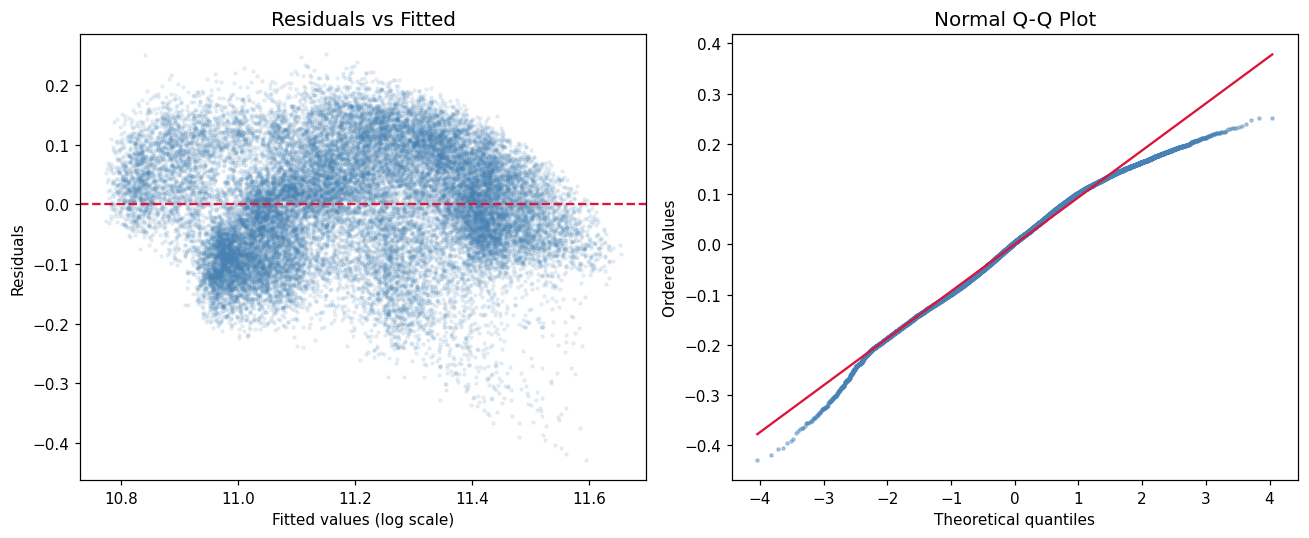

In [5]:
fitted    = gam.predict(X_train)
residuals = y_train - fitted

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(fitted, residuals, alpha=0.1, s=4, color='steelblue')
axes[0].axhline(0, color='crimson', lw=1.5, ls='--')
axes[0].set_xlabel('Fitted values (log scale)')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted')

stats.probplot(residuals, dist='norm', plot=axes[1])
axes[1].set_title('Normal Q-Q Plot')
axes[1].get_lines()[0].set(markersize=2, alpha=0.4, color='steelblue')
axes[1].get_lines()[1].set(color='crimson')

plt.tight_layout()
plt.savefig('../outputs/figures/05_gam/05_14_gam_diagnostics.png', bbox_inches='tight')
plt.show()

## 5. Test Set Predictions

In [6]:
y_pred_log = gam.predict(X_test)
y_pred     = np.exp(y_pred_log)
y_actual   = np.exp(y_test)

rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
mae  = mean_absolute_error(y_actual, y_pred)

print(f'RMSE : {rmse:,.1f} kW  ({rmse / y_actual.mean() * 100:.1f}% of mean)')
print(f'MAE  : {mae:,.1f} kW  ({mae  / y_actual.mean() * 100:.1f}% of mean)')

RMSE : 7,199.8 kW  (9.7% of mean)
MAE  : 5,829.1 kW  (7.9% of mean)


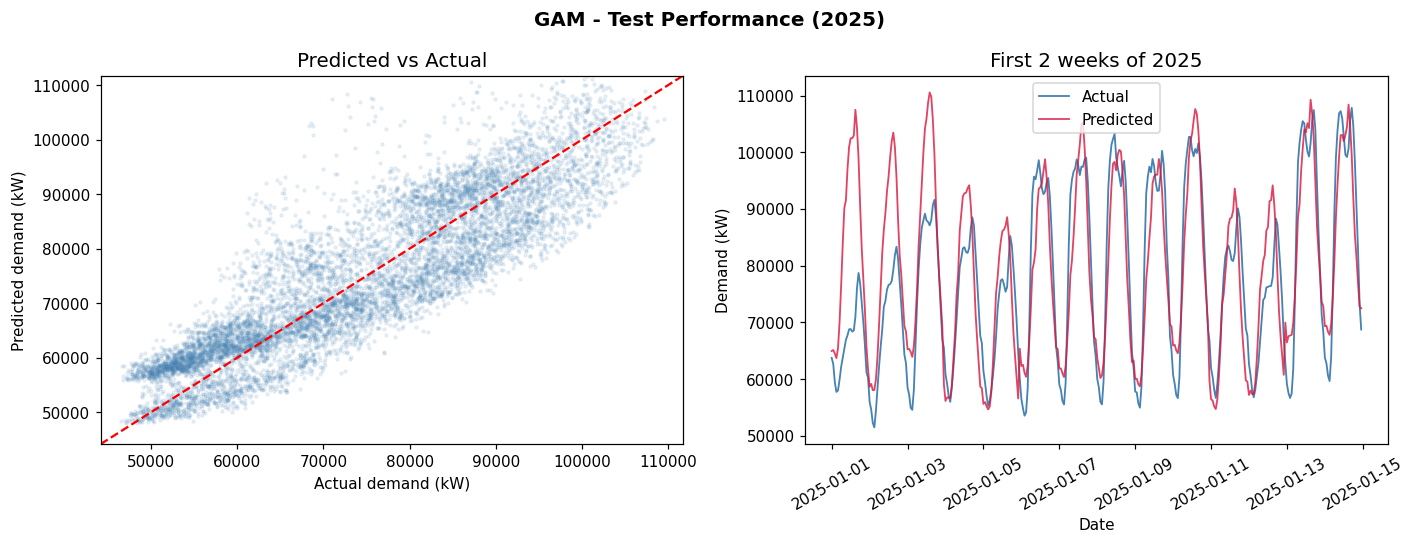

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# scatter predicted vs actual
lim = [y_actual.min() * 0.95, y_actual.max() * 1.02]
axes[0].scatter(y_actual, y_pred, alpha=0.1, s=4, color='steelblue')
axes[0].plot(lim, lim, 'r--', lw=1.5)
axes[0].set_xlim(lim); axes[0].set_ylim(lim)
axes[0].set_xlabel('Actual demand (kW)')
axes[0].set_ylabel('Predicted demand (kW)')
axes[0].set_title('Predicted vs Actual')

# first 2 weeks of 2025 — same window as the LM for visual comparison
two_weeks = test.iloc[:24*14]
y_tw_actual = np.exp(two_weeks['demand_log'].values)
y_tw_pred   = np.exp(gam.predict(two_weeks[FEATURES].values))

axes[1].plot(two_weeks.index, y_tw_actual, lw=1.2, label='Actual',    color='steelblue')
axes[1].plot(two_weeks.index, y_tw_pred,   lw=1.2, label='Predicted', color='crimson', alpha=0.8)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Demand (kW)')
axes[1].set_title('First 2 weeks of 2025')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=30)

fig.suptitle('GAM - Test Performance (2025)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/05_gam/05_15_gam_pred_vs_actual.png', bbox_inches='tight')
plt.show()

#### 6. Comparison with LM

T has a non-linear effect: steep drop at low temperatures, flatter at high ones.
The LM can only approximate this with a linear term. Same pattern for StrGlo.
Lower RMSE/MAE vs the LM would mean the splines are actually helping.

## 7. Save Metrics

In [8]:
new_row = pd.DataFrame([{
    'model':    'GAM',
    'rmse':     round(rmse, 1),
    'mae':      round(mae, 1),
    'r2_train': round(gam.statistics_['pseudo_r2']['explained_deviance'], 4),
    'auc':      np.nan
}])

out = '../outputs/model_comparison.csv'
if os.path.exists(out):
    existing = pd.read_csv(out)
    existing = existing[existing['model'] != 'GAM']
    new_row = pd.concat([existing, new_row], ignore_index=True)

new_row.to_csv(out, index=False)
print(new_row.to_string())

          model      rmse       mae  r2_train     auc
0            LM  7623.700  6125.800    0.7855     NaN
1   GLM_Poisson     2.575     1.441    0.6887     NaN
2  GLM_Binomial       NaN       NaN    0.5254  0.9593
3           GAM  7199.800  5829.100    0.8081     NaN
